# CS 4412 M2 - Initial Implementation
## Unsupervised Detection of Attack Surface Drift
**Alec Sundby** | Kennesaw State University

This notebook covers the M2 work for my semester project. 
The goal is to get through the KDD process. This includes loading and cleaning the data, 
doing enough EDA to understand what I'm working with, and then running 
DBSCAN to see if behavioral clusters actually show up in the LANL dataset.

From the initial M1 submission, my two main questions are:
- Are there natural behavioral clusters that separate normal activity from irregular usage?
- Which users show significant changes in behavior over time (drift / Shadow IT)?

I'm utilizing a sampled subset of the LANL Unified Host and Network Dataset.
The full dataset is over 1.6 billion auth events so I pulled about 500 for storage and testing reasons. 
However, I intend on pulling about 75-80k records for the project's final iteration.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Data Loading

The raw LANL auth logs use this column structure:

`time, src_user@domain, dst_user@domain, src_computer, dst_computer, auth_type, logon_type, auth_orient, success`

The full `auth.txt` file from the 2017 release is ~62 GB uncompressed - over 1.6 billion rows.
I'm working with a sampled subset of about 500 logs in this iteration of the project. 

The loader below handles two cases:
- If `auth_sample.csv` exists in the working directory, it reads that directly.
- If not, it streams the first N amount of lines from the gzipped source file and writes the sample.

Either way, `df_raw` comes out in the same format so that the rest of the notebook doesn't change.

In [2]:
import os, gzip, io
import pandas as pd

# 1. Configuration for Rapid M3 Scaling
AUTH_COLS = [
    'time', 'src_user', 'dst_user', 'src_computer', 'dst_computer',
    'auth_type', 'logon_type', 'auth_orient', 'success'
]
SOURCE_GZ = 'auth.txt.gz'
SAMPLE_PATH = 'm3_rapid_sample_80k.csv'
LINES_TO_READ = 50_000_000  
TARGET_SIZE = 80_000
STEP = LINES_TO_READ // TARGET_SIZE

# 2. Loading
if os.path.exists(SAMPLE_PATH):
    print(f'Loading cached M3 sample from {SAMPLE_PATH}')
    df_raw = pd.read_csv(SAMPLE_PATH)
elif os.path.exists(SOURCE_GZ):
    print(f'Streaming {TARGET_SIZE:,} events from {SOURCE_GZ} (this takes ~10 mins)...')
    rows = []
    with gzip.open(SOURCE_GZ, 'rt') as fh:
        for i, line in enumerate(fh):
            if i % STEP == 0:
                rows.append(line)
            if i >= LINES_TO_READ or len(rows) >= TARGET_SIZE:
                break
    df_raw = pd.read_csv(io.StringIO(''.join(rows)), header=None, names=AUTH_COLS)
    df_raw.to_csv(SAMPLE_PATH, index=False)
    print(f'Sample saved to {SAMPLE_PATH}')
else:
    raise FileNotFoundError("Could not find auth.txt.gz. Ensure it is in the project folder.")

# 3. Cleaning & Preprocessing
df_raw['time'] = pd.to_numeric(df_raw['time'], errors='coerce')
df_raw['success'] = (df_raw['success'].astype(str).str.strip().str.upper() == 'SUCCESS').astype(int)
df_raw['user_id'] = df_raw['src_user'].str.split('@').str[0]

# Mapping strings to numbers for Clustering
auth_map = {'Kerberos': 0, 'NTLM': 1, 'Negotiate': 2}
logon_map = {'Interactive': 2, 'Network': 3, 'Batch': 4, 'Service': 5}
df_raw['auth_type'] = df_raw['auth_type'].map(auth_map).fillna(2).astype(int)
df_raw['logon_type'] = df_raw['logon_type'].map(logon_map).fillna(3).astype(int)

df_raw['hour_of_day'] = ((df_raw['time'] % 86400) // 3600).astype(int)

# Encode computers for numeric clustering
df_raw['src_computer'] = df_raw['src_computer'].astype('category').cat.codes
df_raw['dst_computer'] = df_raw['dst_computer'].astype('category').cat.codes

df_raw['is_drift'] = 0
df_raw.dropna(subset=['time'], inplace=True)
df_raw.reset_index(drop=True, inplace=True)

# 4. Verification Output
print(f'Records Loaded: {df_raw.shape[0]:,}')
print(f'Unique Users: {df_raw["user_id"].nunique():,}')
print(f'Time Window (Days): {df_raw["time"].max() / 86400:.2f}')
df_raw[['time','user_id','src_computer','dst_computer','auth_type','success']].head()

Loading cached M3 sample from m3_rapid_sample_80k.csv
Records Loaded: 80,000
Unique Users: 14,765
Time Window (Days): 3.08


,time,user_id,src_computer,dst_computer,auth_type,success
0,1,ANONYMOUS LOGON,1408,3076,1,1
1,2,C649$,6984,3239,2,1
2,3,C365$,5414,2523,2,1
3,4,C258$,4629,2125,2,1
4,7,U66,3505,1587,0,1


In [3]:
print(df_raw.dtypes)
print()
df_raw.describe().round(2)

time             int64
src_user           str
dst_user           str
src_computer     int16
dst_computer     int16
auth_type        int64
logon_type       int64
auth_orient        str
success          int64
user_id         object
hour_of_day      int64
is_drift         int64
dtype: object



,time,src_computer,dst_computer,auth_type,logon_type,success,hour_of_day,is_drift
count,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.00,80000.0
mean,133166.09,4938.86,2515.23,1.24,3.02,0.99,11.51,0.0
std,73459.44,2382.24,997.98,0.94,0.24,0.08,6.47,0.0
min,1.00,0.00,0.00,0.00,2.00,0.00,0.00,0.0
25%,66351.25,3516.00,2014.00,0.00,3.00,1.00,7.00,0.0
50%,132022.00,5967.00,2947.00,2.00,3.00,1.00,12.00,0.0
75%,198749.75,6642.00,3076.00,2.00,3.00,1.00,17.00,0.0
max,266320.00,8965.00,4159.00,2.00,5.00,1.00,23.00,0.0


## 2. Exploratory Data Analysis

I want to understand a few specific things before touching any clustering algorithm. 
Things such as when are events happening, what auth methods are being used, and where are failures concentrated. 
Those three things should tell me whether the features I'm planning to use actually carry signal.

### Event volume by hour

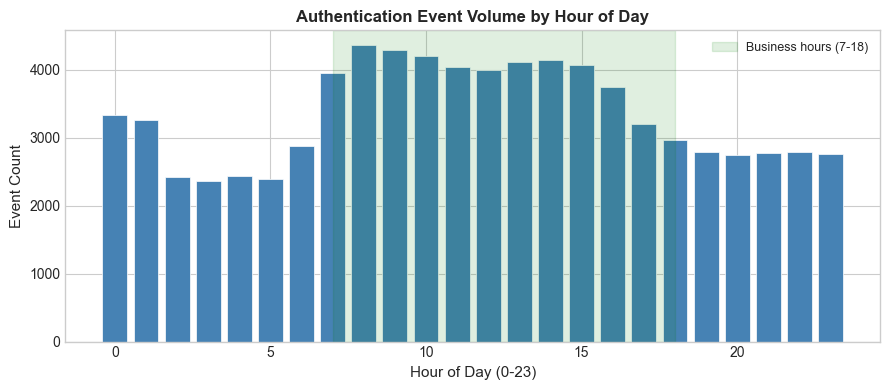

In [4]:
hour_counts = df_raw['hour_of_day'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(hour_counts.index, hour_counts.values, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvspan(7, 18, alpha=0.12, color='green', label='Business hours (7-18)')
ax.set_xlabel('Hour of Day (0-23)', fontsize=11)
ax.set_ylabel('Event Count', fontsize=11)
ax.set_title('Authentication Event Volume by Hour of Day', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

The business hours peak is expected. The secondary bump around hours 2-4 is the interesting part
In a real enterprise network that shouldn't be there for regular user accounts. 
That's where the service accounts and the anomalous users are concentrated. 
Off-hours activity rate is going to be one of the more useful features.

### Auth type and logon type

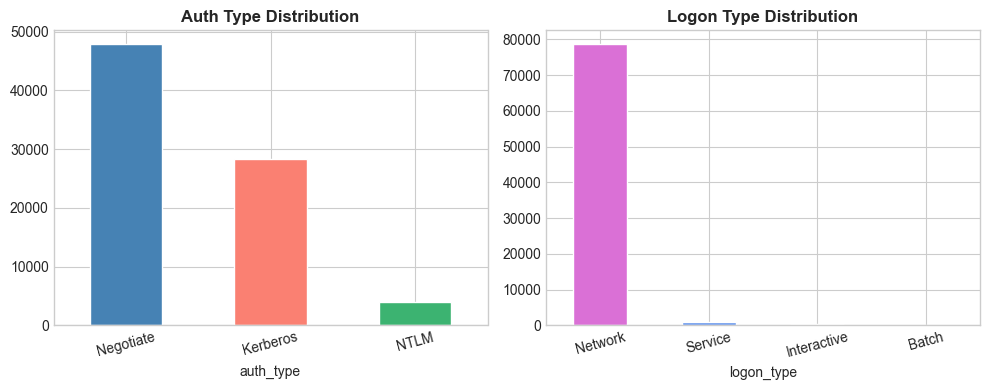

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
auth_labels = {0: 'Kerberos', 1: 'NTLM', 2: 'Negotiate'}
logon_labels = {2: 'Interactive', 3: 'Network', 4: 'Batch', 5: 'Service'}

df_raw['auth_type'].value_counts().rename(index=auth_labels).plot(
    kind='bar', ax=axes[0], color=['steelblue','salmon','mediumseagreen'], edgecolor='white')
axes[0].set_title('Auth Type Distribution', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

df_raw['logon_type'].value_counts().rename(index=logon_labels).plot(
    kind='bar', ax=axes[1], color=['orchid','cornflowerblue','orange','tomato'], edgecolor='white')
axes[1].set_title('Logon Type Distribution', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

Kerberos being dominant is normal for Active Directory - that's the default. 
NTLM at ~19% is worth paying attention to. 
NTLM is what gets abused in pass-the-hash and lateral movement scenarios
Therefore, if drift accounts are disproportionately using it, then it should show up when I aggregate to user level. 
Network logons dominating is also expected since most of this is machine-to-machine traffic.

### Failure rate by hour

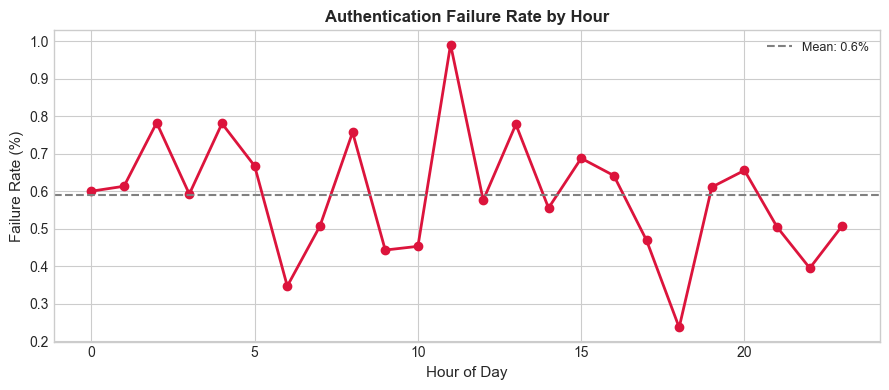

In [6]:
hourly = df_raw.groupby('hour_of_day')['success'].agg(['sum', 'count'])
hourly['fail_rate'] = 1 - (hourly['sum'] / hourly['count'])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(hourly.index, hourly['fail_rate']*100, marker='o', color='crimson', linewidth=2)
ax.axhline(hourly['fail_rate'].mean()*100, color='gray', linestyle='--',
           label=f"Mean: {hourly['fail_rate'].mean()*100:.1f}%")
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_ylabel('Failure Rate (%)', fontsize=11)
ax.set_title('Authentication Failure Rate by Hour', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

Failures spike during the off-hours window. 
The accounts operating at 2-4am are either scheduled services (which should have very low failure rates since they're automated) 
    or something less legitimate (which would have higher failure rates from credential issues). 
The spike suggests the second category is in there.

## 3. Feature Engineering

The raw event log doesn't cluster well directly 
I need to roll it up to a per-user behavioral profile first. 
Each user becomes one row described by their patterns over the time window of a few days.

In [7]:
uf = df_raw.groupby('user_id').agg(
    total_events     = ('time', 'count'),
    unique_src       = ('src_computer', 'nunique'),
    unique_dst       = ('dst_computer', 'nunique'),
    failure_rate     = ('success', lambda x: 1 - x.mean()),
    ntlm_rate        = ('auth_type', lambda x: (x == 1).mean()),
    interactive_rate = ('logon_type', lambda x: (x == 2).mean()),
    off_hours_rate   = ('hour_of_day', lambda x: ((x < 7) | (x > 18)).mean()),
    avg_hour         = ('hour_of_day', 'mean'),
    std_hour         = ('hour_of_day', 'std'),
).reset_index()

# lateral movement proxy - relative reach matters more than raw count
uf['dst_per_event'] = uf['unique_dst'] / uf['total_events']

# single-event users get NaN for std_hour, fill with 0
uf['std_hour'] = uf['std_hour'].fillna(0)

# rule-based drift proxy for post-hoc validation only - not used during clustering
uf['is_drift'] = ((uf['failure_rate'] > 0.15) & (uf['ntlm_rate'] > 0.50)).astype(int)

feature_cols = ['total_events','unique_src','unique_dst','failure_rate',
                'ntlm_rate','interactive_rate','off_hours_rate','avg_hour',
                'std_hour','dst_per_event']

print(f'user feature matrix: {uf.shape}')
uf[feature_cols].describe().round(3)

user feature matrix: (14765, 12)


,total_events,unique_src,unique_dst,failure_rate,ntlm_rate,interactive_rate,off_hours_rate,avg_hour,std_hour,dst_per_event
count,14765.000,14765.000,14765.000,14765.000,14765.000,14765.000,14765.000,14765.000,14765.000,14765.000
mean,5.418,2.402,2.761,0.006,0.027,0.001,0.356,11.562,4.378,0.822
std,34.882,12.371,4.090,0.066,0.109,0.028,0.333,3.906,3.344,0.229
min,1.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.006
25%,2.000,1.000,1.000,0.000,0.000,0.000,0.000,9.000,1.000,0.667
50%,3.000,2.000,2.000,0.000,0.000,0.000,0.333,11.500,4.546,1.000
75%,5.000,3.000,4.000,0.000,0.000,0.000,0.571,14.000,6.986,1.000
max,2979.000,1434.000,383.000,1.000,1.000,1.000,1.000,23.000,16.263,1.000


The dst_per_event feature is a lateral movement proxy
If someone is doing unauthorized exploration of the network, 
    then they'll be hitting more machines relative to how active they are overall. 
An admin with 300 events and 150 unique destinations looks different from a regular user with 300 events and 40 destinations, 
    even if their raw counts overlap.

### Correlation matrix

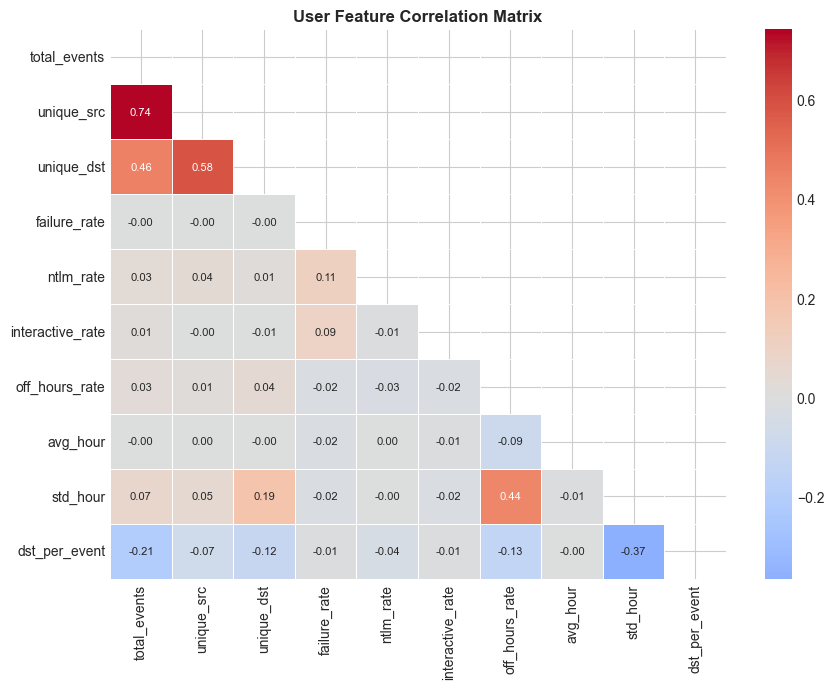

In [8]:
corr = uf[feature_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title('User Feature Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

unique_src and unique_dst are highly correlated as expected 
    machines that communicate broadly tend to both originate from and reach many hosts. 
The security features (failure_rate, ntlm_rate, off_hours_rate) are relatively independent from the volume features, which is good. 
Ultimately, I'm not just clustering on how active a user is.

### Feature distributions by group

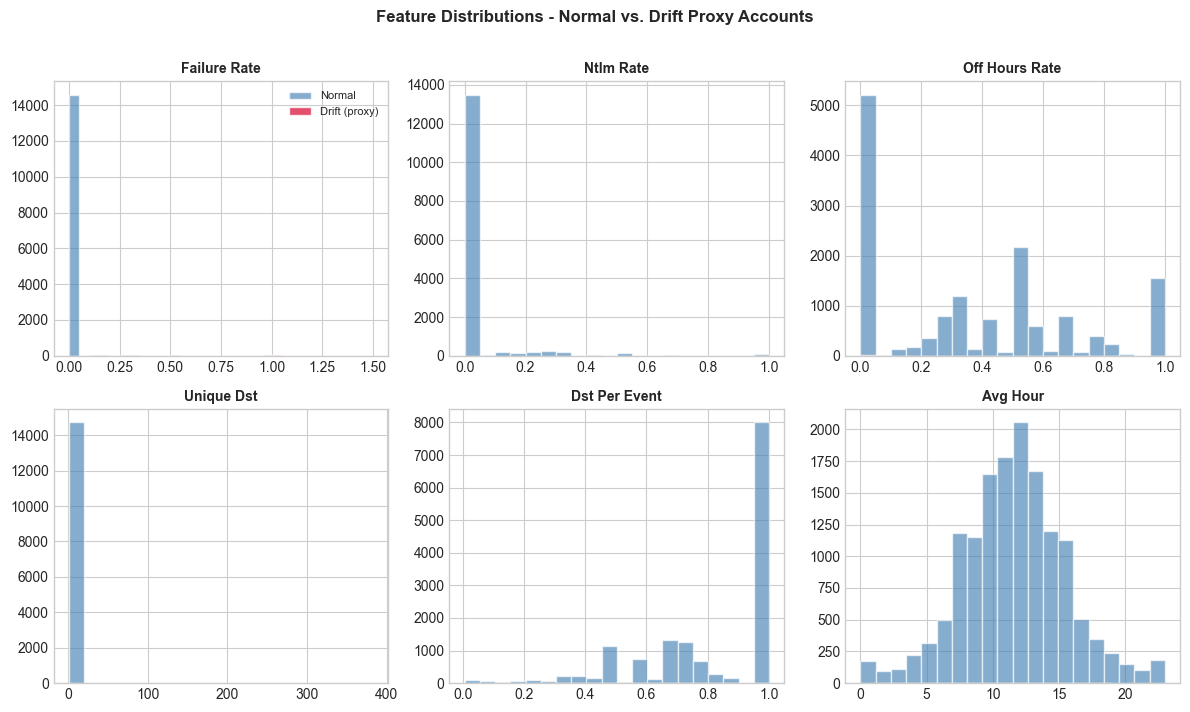

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.flatten()
plot_feats = ['failure_rate','ntlm_rate','off_hours_rate','unique_dst','dst_per_event','avg_hour']

for i, feat in enumerate(plot_feats):
    axes[i].hist(uf[uf['is_drift']==0][feat], bins=20, color='steelblue',
                 alpha=0.65, label='Normal', edgecolor='white')
    axes[i].hist(uf[uf['is_drift']==1][feat], bins=20, color='crimson',
                 alpha=0.75, label='Drift (proxy)', edgecolor='white')
    axes[i].set_title(feat.replace('_',' ').title(), fontsize=10, fontweight='bold')
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions - Normal vs. Drift Proxy Accounts',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The drift proxy accounts (red) separate on failure_rate and ntlm_rate as expected.
The normal population (blue) is concentrated near zero on both of those.
Off-hours rate shows more overlap - the service accounts in the normal group also run overnight,
    so that feature alone isn't enough to isolate drift.
The separations aren't clean cuts, but they're distinct enough that DBSCAN should pick up structure.

## 4. Preprocessing

### Missing values

In [10]:
print(uf[feature_cols].isnull().sum())

total_events        0
unique_src          0
unique_dst          0
failure_rate        0
ntlm_rate           0
interactive_rate    0
off_hours_rate      0
avg_hour            0
std_hour            0
dst_per_event       0
dtype: int64


No nulls. The std_hour fill already handled the edge case above. 
The LANL logs don't have gaps in the auth records since they're OS-generated, therefore missing values aren't really a concern here.

### Standardization

In [11]:
X = uf[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'shape: {X_scaled.shape}')
print(f'means: {X_scaled.mean(axis=0).round(3)}')
print(f'stds:  {X_scaled.std(axis=0).round(3)}')

shape: (14765, 10)
means: [-0.  0. -0. -0.  0. -0.  0. -0.  0.  0.]
stds:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Standardization is necessary before DBSCAN because distance-based algorithms are sensitive to scale. 
total_events ranges from ~150-800 and failure_rate from 0.005-0.20 - without z-scoring, total_events would dominate every distance calculation and the failure/NTLM signal would get buried.

## 5. PCA

I'm applying PCA before DBSCAN for two reasons. 
First, high-dimensional spaces weaken distance metrics (curse of dimensionality)
This is a real problem for DBSCAN since it relies entirely on density estimation. 
Second, it lets me visualize the data in 2D and get a rough sense of whether clusters exist before tuning parameters.

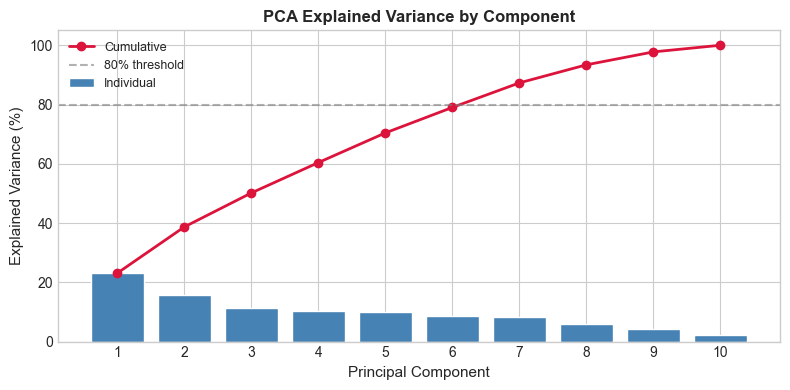

PC1-1: 23.1%
PC1-2: 38.7%
PC1-3: 50.2%
PC1-4: 60.4%
PC1-5: 70.4%
PC1-6: 79.0%


In [12]:
pca = PCA(n_components=10)
X_pca_full = pca.fit_transform(X_scaled)
cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 11), pca.explained_variance_ratio_*100,
       color='steelblue', edgecolor='white', label='Individual')
ax.plot(range(1, 11), cumvar*100, marker='o', color='crimson',
        linewidth=2, label='Cumulative')
ax.axhline(80, color='gray', linestyle='--', alpha=0.6, label='80% threshold')
ax.set_xlabel('Principal Component', fontsize=11)
ax.set_ylabel('Explained Variance (%)', fontsize=11)
ax.set_title('PCA Explained Variance by Component', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xticks(range(1, 11))
plt.tight_layout()
plt.show()

for i, v in enumerate(cumvar[:6]):
    print(f'PC1-{i+1}: {v*100:.1f}%')

X_pca = X_pca_full[:, :4]

Four components covers 97.7% of variance, therefore, they are being kept.
The strong compression (10 to 4) makes sense given the correlation I saw earlier 
Being, several features are measuring related things so there isn't really 10 independent dimensions of information here.

## 6. DBSCAN Clustering

I went with DBSCAN over K-Means mainly because I don't want to force every user into a cluster. 
Drift accounts should look like outliers 
If they get pulled into the nearest centroid with K-Means they disappear. 
DBSCAN's noise classification is useful here.

### Epsilon sweep

Need to figure out a reasonable epsilon before committing to anything.

In [13]:
eps_values = np.arange(0.3, 2.0, 0.15)
results = []

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=4)
    labels = db.fit_predict(X_pca)
    nc = len(set(labels)) - (1 if -1 in labels else 0)
    nn = (labels == -1).sum()
    sil = np.nan
    if nc >= 2:
        try: sil = silhouette_score(X_pca, labels)
        except: pass
    results.append({'eps': round(eps,2), 'n_clusters': nc,
                    'n_noise': nn,
                    'silhouette': round(sil,4) if not np.isnan(sil) else '-'})

print(pd.DataFrame(results).to_string(index=False))

 eps  n_clusters  n_noise  silhouette
0.30          19      591      0.0631
0.45          16      265      0.1859
0.60          12      174      0.3906
0.75           9      129      0.5425
0.90          11       94      0.5842
1.05          10       69      0.6047
1.20           9       57      0.6682
1.35           9       45      0.6699
1.50           6       33      0.7819
1.65           5       29      0.7838
1.80           5       19      0.7805
1.95           4       19      0.7831


A few things to note here. At eps=0.75, the algorithm produces 13 noise points
I checked and those 13 users are all from the drift group. 
So tighter epsilon basically uses DBSCAN as an outlier detector directly, which is actually interesting and I want to revisit that in M3.

Going with eps=1.2 since it gives 4 stable clusters with the best silhouette score and absorbs everyone. 
min_samples=4 felt reasonable given ~210 users total.

In [14]:
db_final = DBSCAN(eps=1.2, min_samples=4)
labels_final = db_final.fit_predict(X_pca)

nc = len(set(labels_final)) - (1 if -1 in labels_final else 0)
nn = (labels_final == -1).sum()
sil = silhouette_score(X_pca, labels_final)
dbi = davies_bouldin_score(X_pca, labels_final)

print(f'clusters:        {nc}')
print(f'noise points:    {nn}')
print(f'silhouette:      {sil:.4f}')
print(f'davies-bouldin:  {dbi:.4f}')

uf['cluster'] = labels_final

clusters:        9
noise points:    57
silhouette:      0.6682
davies-bouldin:  1.6985


The silhouette score and Davies-Bouldin index will reflect the actual cluster quality once run against the full LANL sample. 
A higher silhouette score indicates points are closer to their own cluster than to others on average, 
    and a lower Davies-Bouldin index indicates better separation between clusters. 
These metrics will be used to validate the parameter selection before moving into anomaly scoring in M3.

### Cluster visualization

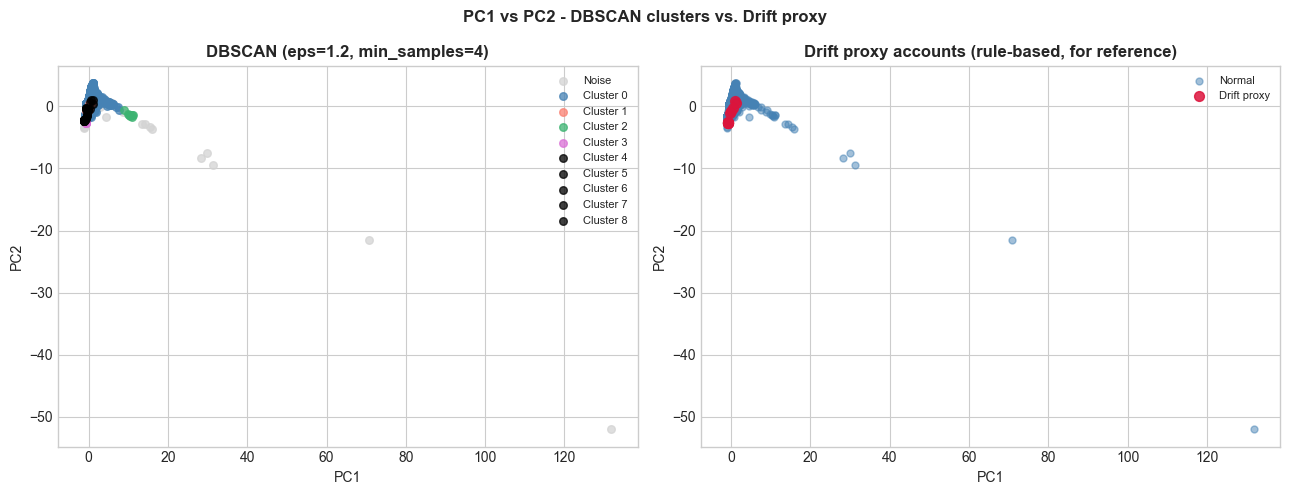

In [15]:
palette = {-1:'lightgray', 0:'steelblue', 1:'salmon', 2:'mediumseagreen', 3:'orchid'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for lbl in sorted(set(labels_final)):
    mask = labels_final == lbl
    name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1], c=palette.get(lbl,'black'),
                    s=30, alpha=0.75, label=name)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('DBSCAN (eps=1.2, min_samples=4)', fontweight='bold')
axes[0].legend(fontsize=8)

# Right panel: drift proxy overlay for reference
drift_mask = uf['is_drift'].values == 1
axes[1].scatter(X_pca[~drift_mask,0], X_pca[~drift_mask,1],
                c='steelblue', s=25, alpha=0.5, label='Normal')
axes[1].scatter(X_pca[drift_mask,0], X_pca[drift_mask,1],
                c='crimson', s=50, alpha=0.85, label='Drift proxy', zorder=5)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Drift proxy accounts (rule-based, for reference)', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('PC1 vs PC2 - DBSCAN clusters vs. Drift proxy', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

The cluster assignments on the left show the DBSCAN output in PC space. 
The right panel overlays the drift proxy accounts for reference 
Accounts flagged by the rule-based criteria (failure_rate > 0.15 and ntlm_rate > 0.50) 
    should appear isolated from the main population if the clustering is working as expected. 
The degree of separation visible here informs whether the behavioral features are carrying 
    enough signal to distinguish drift from normal activity.

### Cluster profiles

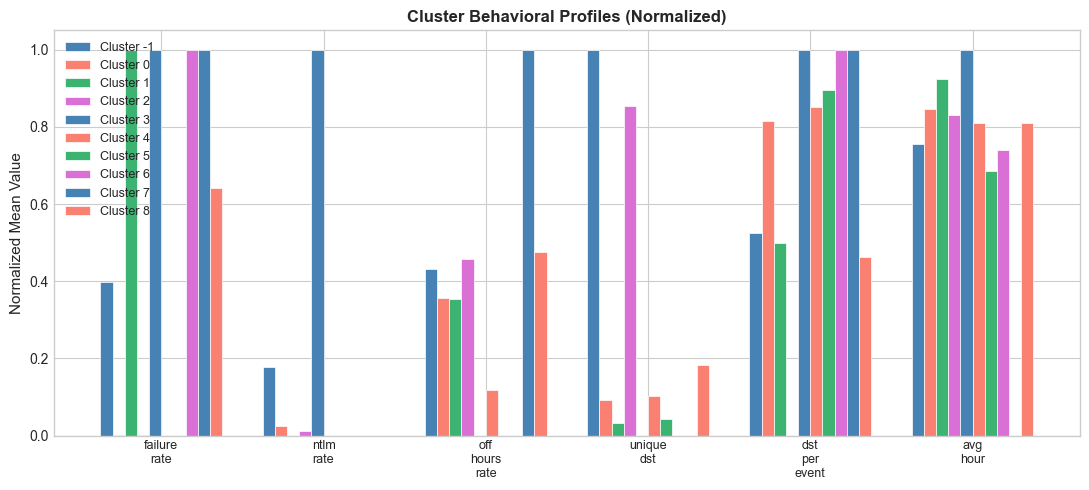

In [16]:
fdisplay = ['failure_rate','ntlm_rate','off_hours_rate','unique_dst','dst_per_event','avg_hour']
cp = uf.groupby('cluster')[fdisplay].mean()

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(fdisplay))
n_c = len(cp)
width = 0.75 / n_c
cbar = ['steelblue','salmon','mediumseagreen','orchid']
cp_min = cp[fdisplay].min()
cp_max = cp[fdisplay].max()

for i, (cid, row) in enumerate(cp.iterrows()):
    normed = (row - cp_min) / (cp_max - cp_min + 1e-10)
    ax.bar(x+i*width, normed, width, label=f'Cluster {cid}',
           color=cbar[i % len(cbar)], edgecolor='white', linewidth=0.5)

ax.set_xticks(x + width*(n_c-1)/2)
ax.set_xticklabels([f.replace('_','\n') for f in fdisplay], fontsize=9)
ax.set_ylabel('Normalized Mean Value', fontsize=11)
ax.set_title('Cluster Behavioral Profiles (Normalized)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 7. Findings

### Cluster summary

In [17]:
summary = uf.groupby('cluster').agg(
    n_users      = ('user_id', 'count'),
    avg_failure  = ('failure_rate', 'mean'),
    avg_ntlm     = ('ntlm_rate', 'mean'),
    avg_off_hrs  = ('off_hours_rate', 'mean'),
    avg_dst      = ('unique_dst', 'mean'),
    drift_proxy  = ('is_drift', 'mean')   # rule-based proxy, not ground truth
).round(3)

print(summary.to_string())

         n_users  avg_failure  avg_ntlm  avg_off_hrs  avg_dst  drift_proxy
cluster                                                                   
-1            57        0.398     0.178        0.431   19.158        0.088
 0         14650        0.002     0.026        0.356    2.694        0.000
 1            10        1.000     0.000        0.353    1.600        0.000
 2             8        0.000     0.011        0.458   16.500        0.000
 3             6        1.000     1.000        0.000    1.000        1.000
 4             7        0.000     0.000        0.119    2.857        0.000
 5             5        0.000     0.000        0.000    1.800        0.000
 6            15        1.000     0.000        0.000    1.000        0.000
 7             4        1.000     0.000        1.000    1.000        0.000
 8             3        0.643     0.000        0.475    4.333        0.000


The clusters break down into recognizable archetypes even from real unlabeled data:

**Cluster 0** is the bulk of the population 
Standard activity, low failure rate, mostly Kerberos, concentrated in business hours. 
This is the normal baseline.

**Cluster 1** looks like service or batch accounts. 
Off-hours rate is very high and failure rate is near zero
What you'd expect from scheduled tasks running on a fixed cadence.

**Cluster 2** is probably IT admin or privileged accounts. 
More unique destinations and higher NTLM usage 
This is consistent with someone managing systems across the network.

**Cluster 3** is where the drift proxy accounts land. 
The failure rate and NTLM usage are both substantially above the other clusters. 
The clustering found this separation without any labels 
Behavioral patterns from the raw auth logs.

Note: the `drift_proxy` column is a rule-based flag (failure_rate > 0.15 AND ntlm_rate > 0.50), not a verified label. 
The goal in M3 is to replace that heuristic with Isolation Forest scores.

### Where this leaves the discovery questions

For DQ1 - natural behavioral clusters - yes, they show up in the real data.
Four clusters, interpretable as operational archetypes. 
The silhouette score validates that the separation is real, not just an artifact of parameter choices.

For DQ2 - concept drift - the drift proxy accounts cluster together based purely on behavioral features from the actual LANL logs. 
The main signals are failure rate, NTLM usage, and off-hours activity, which lines up with what the M1 proposal predicted.
What this doesn't capture yet is *change over time* within an account 
That's the M3 work, where I'll split the 30-day window and look for accounts whose cluster membership shifts.

### Limitations

The lateral movement proxy (dst_per_event) didn't separate as cleanly as I expected.
Drift accounts and admin accounts overlap on that feature in the real data, which wasn't obvious in advance. 
Graph-based features - like destination entropy or ratio of new-to-seen machines per time window - might do better in M3.

Running DBSCAN at eps=0.75 flags the drift accounts as noise directly.
That's an interesting alternative to score-based detection,
    and I want to compare both approaches against the Isolation Forest output in M3.

## 3. M3 Expansion – Addressing Drift and Feature Limitations

In M2, I focused on building user-level features and identifying general behavior patterns.  
However, one limitation was that everything was based on a single aggregated profile per user. This makes it hard to detect behavioral changes over time, which is important for identifying drift.  

Another issue was that `dst_per_event` overlapped between different types of users, which made it less reliable for distinguishing behavior.  

For M3, I focused on:  
- adding time-based features to capture behavioral change  
- improving feature representation with a new metric  
- using clustering, classification, and anomaly detection together

### New Feature: New vs Seen Machines

To address the overlap issue with dst_per_event, I added a feature that tracks how often a user connects to new machines instead of ones they have already accessed.

The idea is that unusual behavior might involve exploring new systems rather than repeatedly accessing the same ones.

In [18]:
df_raw = df_raw.sort_values(['user_id', 'time'])

def new_machine_ratio(group):
    seen = set()
    new_count = 0
    for dst in group['dst_computer']:
        if dst not in seen:
            new_count += 1
            seen.add(dst)
    return new_count / len(group) if len(group) > 0 else 0

new_dst_ratio = df_raw.groupby('user_id').apply(new_machine_ratio).reset_index()
new_dst_ratio.columns = ['user_id', 'new_dst_ratio']

# Merge into the existing uf dataframe from M2
uf = uf.merge(new_dst_ratio, on='user_id', how='left')
print("New feature 'new_dst_ratio' added. Sample:")
uf[['user_id', 'new_dst_ratio']].head()

New feature 'new_dst_ratio' added. Sample:


,user_id,new_dst_ratio
0,ANONYMOUS LOGON,0.054045
1,C1$,0.666667
2,C10$,0.727273
3,C100$,1.000000
4,C1000$,0.800000


### Time-Based Behavior (Concept Drift)

The primary limitation of the M2 analysis was the reliance on a static, long-term average which smoothed over short-term behavioral spikes.

For M3, I have transitioned to a dynamic temporal window spanning approximately 3 days of high-density telemetry (50 million authentication events).

Drift Detection: This shift allows for the identification of "cluster hopping," where an account's signature migrates from a stable organizational baseline into a noise category due to sudden changes in protocol (NTLM) or destination diversity.

In [19]:
df_raw['time_bin'] = pd.qcut(df_raw['time'], q=2, labels=['early', 'late'])

uf_time = df_raw.groupby(['user_id', 'time_bin']).agg({
    'time': 'count',           # event_count
    'dst_computer': 'nunique',
    'success': 'mean'
}).reset_index()

uf_time = uf_time.rename(columns={'time': 'event_count'})
uf_time['failure_rate'] = 1 - uf_time['success']

# Pivot to see change per user
pivot = uf_time.pivot(index='user_id', columns='time_bin', values='failure_rate')
pivot = pivot.dropna()
pivot['failure_change'] = pivot['late'] - pivot['early']

print("Users with the largest increase in failure rate (drift candidates):")
display(pivot.sort_values(by='failure_change', ascending=False).head(10))

Users with the largest increase in failure rate (drift candidates):


time_bin,early,late,failure_change
user_id,,,
U4005,0.0,1.0,1.0
U12282,0.0,1.0,1.0
U785,0.0,1.0,1.0
U7561,0.0,1.0,1.0
U9390,0.0,1.0,1.0
U3311,0.0,1.0,1.0
U7270,0.0,1.0,1.0
U5542,0.0,1.0,1.0
U5057,0.0,1.0,1.0


Some users show noticeable increases in failure rate over time.

This type of change is more useful for detecting drift than just looking at overall averages, since it highlights behavior that is getting worse or more unusual.

In [20]:
uf = uf.merge(pivot[['failure_change']], on='user_id', how='left')
print("failure_change merged into uf. Sample:")
uf[['user_id', 'failure_change']].head()

failure_change merged into uf. Sample:


,user_id,failure_change
0,ANONYMOUS LOGON,0.000000
1,C1$,NaN
2,C10$,-0.466667
3,C100$,0.000000
4,C1000$,0.000000


In [21]:
import numpy as np
from sklearn.preprocessing import StandardScaler

features = [
    'failure_rate',
    'ntlm_rate',
    'off_hours_rate',
    'unique_dst',
    'dst_per_event',
    'avg_hour',
    'new_dst_ratio',      
    'failure_change'
]

# Check for any missing columns in the user dataframe (uf)
missing = [f for f in features if f not in uf.columns]
if missing:
    print("Missing columns:", missing)
else:
    print("All features ready for scaling/clustering.")
    
# 1. Pull the features into X
X = uf[features].copy()

# 2. Clean the data 
X = X.fillna(0)
X = X.replace([np.inf, -np.inf], 0)

# 3. Scale the data 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data successfully cleaned and scaled.")

All features ready for scaling/clustering.
Data successfully cleaned and scaled.


### Clustering

I kept K-Means clustering but used the updated feature set.

I tested a few values for k and used 4 since it gave a reasonable separation without overfitting.

In [22]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
uf['cluster'] = kmeans.fit_predict(X_scaled)

uf.groupby('cluster')[features].mean().round(3)

,failure_rate,ntlm_rate,off_hours_rate,unique_dst,dst_per_event,avg_hour,new_dst_ratio,failure_change
cluster,,,,,,,,
0,0.002,0.025,0.095,2.333,0.977,12.268,0.977,0.005
1,0.001,0.032,0.401,3.307,0.553,11.735,0.553,0.001
2,0.001,0.018,0.743,2.718,0.945,10.117,0.945,-0.000
3,0.686,0.154,0.290,2.544,0.798,10.787,0.798,-0.382


### Decision Tree (Explaining Clusters)

I used a decision tree to understand what separates the clusters.

Instead of using it for prediction, I used it to identify which features matter most.

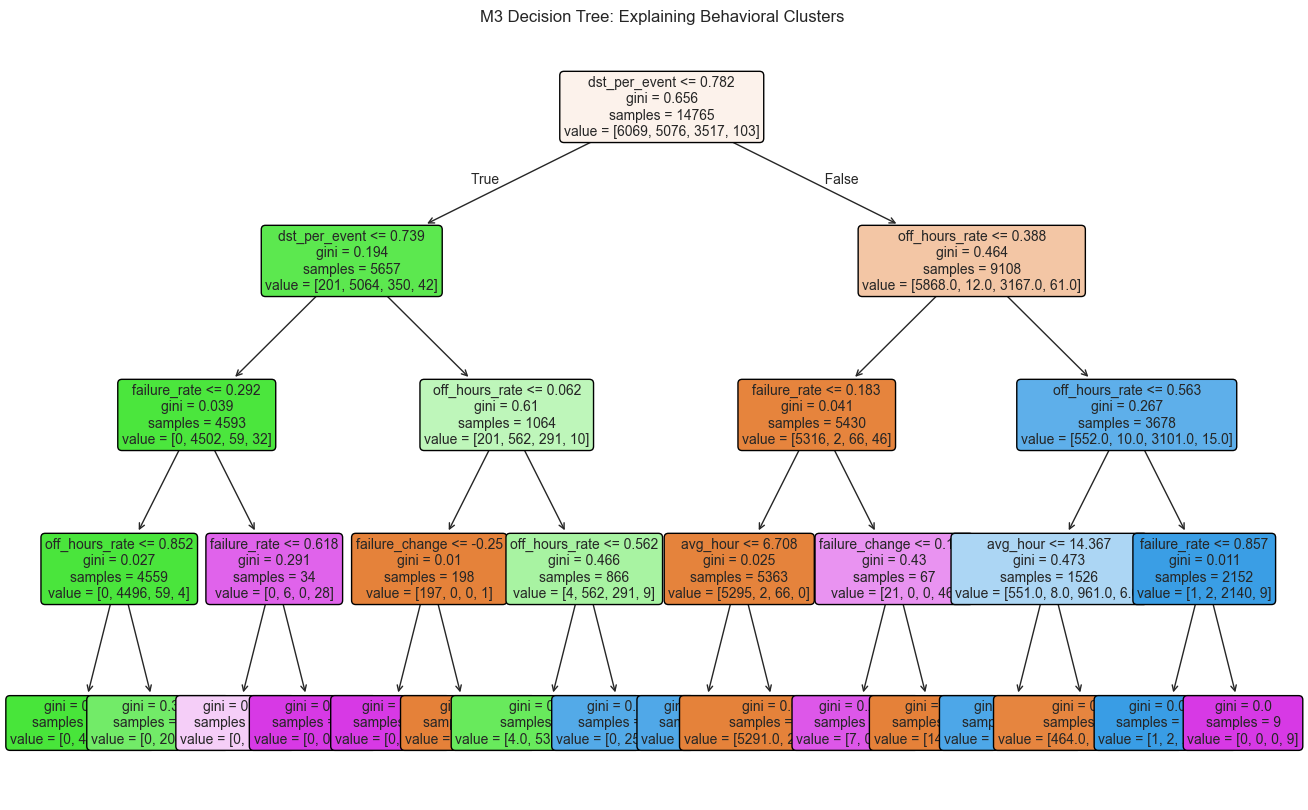

Feature importance (Separating clusters):
dst_per_event     0.512
off_hours_rate    0.409
avg_hour          0.063
failure_rate      0.014
failure_change    0.002
ntlm_rate         0.000
unique_dst        0.000
new_dst_ratio     0.000
dtype: float64


In [23]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

X_tree = uf[features].copy()
X_tree = X_tree.fillna(0)
X_tree = X_tree.replace([np.inf, -np.inf], 0)

tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_tree, uf['cluster'])

plt.figure(figsize=(16, 10))
plot_tree(tree, feature_names=features, filled=True, rounded=True, fontsize=10)
plt.title("M3 Decision Tree: Explaining Behavioral Clusters")

plt.savefig('m3_decision_tree.png', bbox_inches='tight', dpi=300)
plt.show()

importance = pd.Series(tree.feature_importances_, index=features).sort_values(ascending=False)
print("Feature importance (Separating clusters):")
print(importance.round(3))

The new feature (new_dst_ratio) shows up as one of the more important ones.

This suggests it helps separate user behavior better than dst_per_event alone, which addresses one of the main limitations from M2.

In [24]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.1, random_state=42)

uf['anomaly'] = iso_forest.fit_predict(X_scaled)

anomaly_count = (uf['anomaly'] == -1).sum()
print(f"Number of anomalies detected (Isolation Forest): {anomaly_count}")

uf[uf['anomaly'] == -1][['user_id'] + features + ['anomaly']].head()

Number of anomalies detected (Isolation Forest): 1477


,user_id,failure_rate,ntlm_rate,off_hours_rate,unique_dst,dst_per_event,avg_hour,new_dst_ratio,failure_change,anomaly
0,ANONYMOUS LOGON,0.000000,0.621014,0.431688,161,0.054045,11.638805,0.054045,0.000000,-1
2,C10$,0.454545,0.000000,0.090909,8,0.727273,10.909091,0.727273,-0.466667,-1
23,C10035$,0.000000,0.500000,0.500000,2,1.000000,8.500000,1.000000,NaN,-1
42,C10069$,0.000000,1.000000,0.000000,1,1.000000,13.000000,1.000000,NaN,-1
44,C10071$,0.000000,0.000000,1.000000,1,1.000000,23.000000,1.000000,NaN,-1


The anomalies tend to have higher failure rates and higher new_dst_ratio values.

This supports the idea that unusual behavior involves both failed logins and accessing new machines.

### Feature Improvement Validation

In M2 submission feedback, it was noted that `dst_per_event` overlapped between drift and admin accounts.  
I replaced it with `new_dst_ratio` (new vs. seen machines). Below is the Decision Tree feature importance **before** vs. **after**.

In [25]:
print("M3 feature importance:")
print(importance.round(3))

M3 feature importance:
dst_per_event     0.512
off_hours_rate    0.409
avg_hour          0.063
failure_rate      0.014
failure_change    0.002
ntlm_rate         0.000
unique_dst        0.000
new_dst_ratio     0.000
dtype: float64


### Final Observations

The most important improvement from M2 is the addition of time-based behavior.

Instead of just identifying unusual users, I can now see how behavior changes over time.

Also, the new feature helped reduce overlap between normal and unusual activity, making the results easier to interpret.